# Testing
### Häufigste Hauptsprachen (Top 50)

Beschreibung
Die 50 häufigsten Hauptsprachen der 15-Jährigen und Älteren der ständigen Wohnbevölkerung in der Stadt Zürich. Die Auswertung basiert auf dem gepoolten Zielpersonendatensatz der Strukturerhebung.

Datum: 26.02.2026


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_ste_bev_hauptsprachen_top50_od3011

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_ste_bev_hauptsprachen_top50_od3011

### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [3]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [4]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [5]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [6]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [7]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [8]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

#### Zeitvariabeln


In [9]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [10]:
package_name = "bfs_ste_bev_hauptsprachen_top50_od3011"

In [11]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV301OD3011"    
    , datums_attr = None
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_ste_bev_hauptsprachen_top50_od3011/download/BEV301OD3011.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_ste_bev_hauptsprachen_top50_od3011 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_ste_bev_hauptsprachen_top50_od3011 

data_source: web


In [12]:
data2betested.head(2).T

,0,1
Zeitraum,Pooling (2022 bis 2024),Pooling (2022 bis 2024)
Sprache,Deutsch,Englisch
AntBev,73,15
AnzBev,263280,52630
untAntBevKI,73,14
obAntBevKI,74,15
untAnzBevKI,261470,51190
obAnzBevKI,265080,54080


Berechne weitere Attribute falls notwendig

In [13]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
    )
    )
data2betested.dtypes

Zeitraum        object
Sprache         object
AntBev         float64
AnzBev           int64
untAntBevKI    float64
obAntBevKI     float64
untAnzBevKI      int64
obAnzBevKI       int64
dtype: object

### Einfache Datentests

In [14]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Zeitraum     50 non-null     object 
 1   Sprache      50 non-null     object 
 2   AntBev       50 non-null     float64
 3   AnzBev       50 non-null     int64  
 4   untAntBevKI  50 non-null     float64
 5   obAntBevKI   50 non-null     float64
 6   untAnzBevKI  50 non-null     int64  
 7   obAnzBevKI   50 non-null     int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 9.8 KB


In [15]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 50 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [16]:
data2betested.describe()

,AntBev,AnzBev,untAntBevKI,obAntBevKI,untAnzBevKI,obAnzBevKI
count,50,50,50,50,50,50
mean,2,8931,2,3,8593,9269
std,10,37645,10,11,37385,37905
min,0,210,0,0,110,310
25%,0,460,0,0,310,602
50%,0,1115,0,0,880,1345
75%,1,3062,1,1,2682,3440
max,73,263280,73,74,261470,265080


Welches sind die irgendwo keine Werte bei BEW?

In [17]:
data2betested[np.isnan(data2betested.AnzBev)]

,Zeitraum,Sprache,AntBev,AnzBev,untAntBevKI,obAntBevKI,untAnzBevKI,obAnzBevKI


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
#data2betested = data2betested.set_index("StichtagDatJahr")
#data2betested = data2betested.sort_index()

In [19]:
#data2betested.index.year.unique()

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,Zeitraum,Sprache
count,50,50
unique,1,50
top,Pooling (2022 bis 2024),Deutsch
freq,50,1


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AntBev,AnzBev,untAntBevKI,obAntBevKI,untAnzBevKI,obAnzBevKI
count,50,50,50,50,50,50
mean,2,"8,931",2,3,"8,593","9,269"
std,10,"37,645",10,11,"37,385","37,905"
min,0,210,0,0,110,310
25%,0,460,0,0,310,602
50%,0,"1,115",0,0,880,"1,345"
75%,1,"3,062",1,1,"2,682","3,440"
max,73,"263,280",73,74,"261,470","265,080"


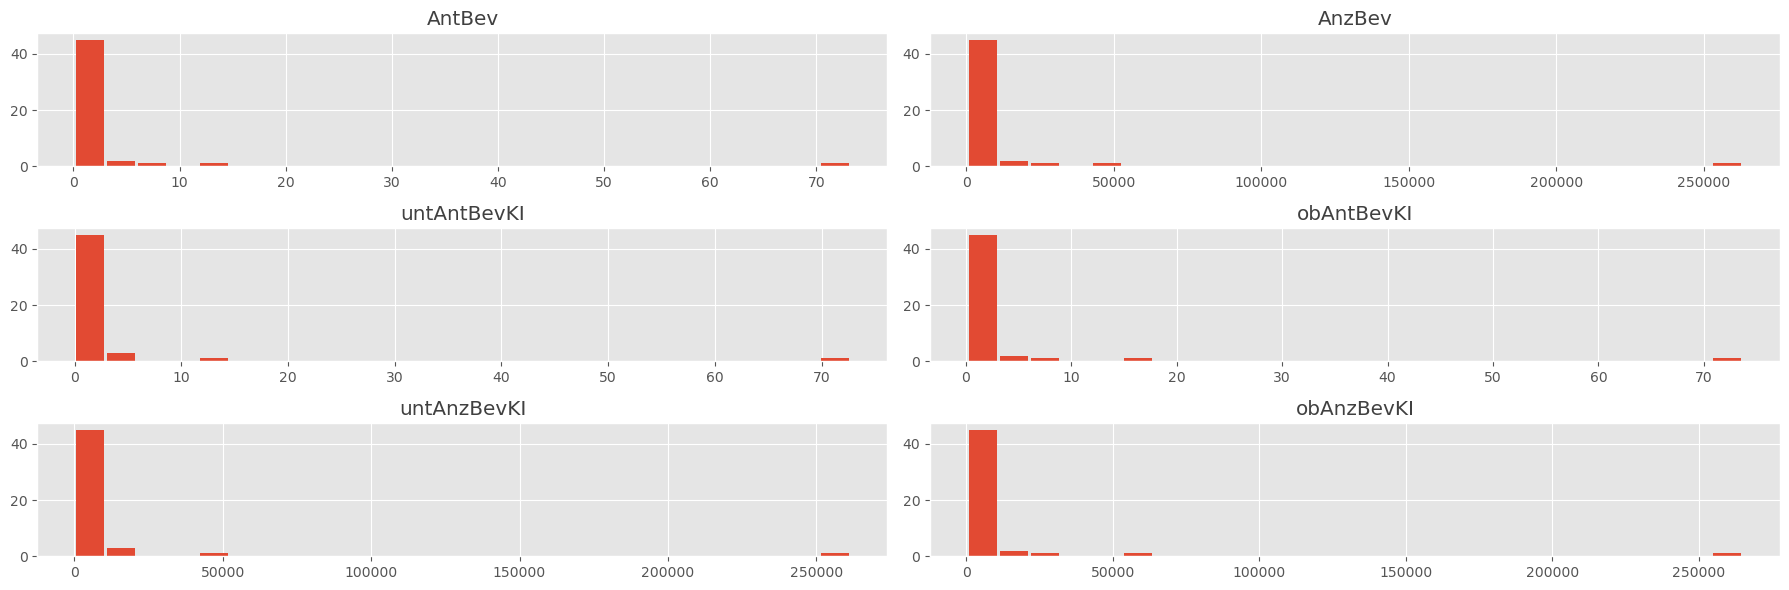

In [22]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,Zeitraum,Sprache,AntBev,AnzBev,untAntBevKI,obAntBevKI,untAnzBevKI,obAnzBevKI


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

Zeitraum       0
Sprache        0
AntBev         0
AnzBev         0
untAntBevKI    0
obAntBevKI     0
untAnzBevKI    0
obAnzBevKI     0
dtype: int64

In [25]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [26]:
agg_pooling = data2betested\
    .groupby(['Zeitraum']) \
    .agg(sum_AnzBev=('AnzBev', 'sum'), sum_AntBev=('AntBev', 'sum')) \
    .sort_values('Zeitraum', ascending=False) 
agg_pooling.reset_index().head(3)

,Zeitraum,sum_AnzBev,sum_AntBev
0,Pooling (2022 bis 2024),446570,124


In [27]:
agg_herk = data2betested\
    .groupby(['Sprache']) \
    .agg(sum_AnzBev=('AnzBev', 'sum'), sum_AntBev=('AntBev', 'sum')) \
    .sort_values('sum_AnzBev', ascending=False) 
agg_herk.reset_index().head(30)

,Sprache,sum_AnzBev,sum_AntBev
0,Deutsch,263280,73
1,Englisch,52630,15
2,Italienisch,21840,6
3,Französisch,17330,5
4,Spanisch,14830,4
5,Serbokroatisch,9600,3
6,Portugiesisch,9370,3
7,Albanisch,6800,2
8,Türkisch,4800,1
9,Russisch,4450,1


### Pivotiere

In [28]:
pivoted_df = data2betested.pivot_table(
    index='Sprache',
    columns= ('Zeitraum'),
    values=['AnzBev', 'untAnzBevKI', 'obAnzBevKI', 'AntBev', 'untAntBevKI', 'obAntBevKI'],
    aggfunc='sum'
)

# Sortieren nach der Aggregation 
pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
#pivoted_df = pivoted_df.sort_index(ascending=True)

# Anzeigen des Ergebnisses
print(pivoted_df)

                                obAnzBevKI                  AnzBev             untAnzBevKI  \
Zeitraum           Pooling (2022 bis 2024) Pooling (2022 bis 2024) Pooling (2022 bis 2024)   
Sprache                                                                                      
Albanisch                             7370                    6800                    6230   
Amharisch                              410                     290                     170   
Arabisch                              3770                    3370                    2960   
Bangala                                400                     280                     160   
Bengalisch                             650                     500                     340   
Bosnisch                               780                     620                     450   
Bulgarisch                             950                     760                     560   
Chinesisch                            2690                  

In [29]:
data2betested.reset_index().columns

Index(['index', 'Zeitraum', 'Sprache', 'AntBev', 'AnzBev', 'untAntBevKI', 'obAntBevKI',
       'untAnzBevKI', 'obAnzBevKI'],
      dtype='object')

#### Barcharts mit Seaborn

In [30]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested

In [31]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

##### Stacked Bar Chart

In [32]:
# Daten vorbereiten

data = data2betested.query("Sprache != 'Deutsch'").reset_index()
data_pivoted = data.pivot(index='Sprache', columns='Zeitraum', values='AnzBev').fillna(0)
#Sortierung nach Maxwert
data_pivoted = data_pivoted.loc[
    data_pivoted.max(axis=1).sort_values(ascending=False).index
]

data_pivoted

Zeitraum,Pooling (2022 bis 2024)
Sprache,
Englisch,52630
Italienisch,21840
Französisch,17330
Spanisch,14830
Serbokroatisch,9600
Portugiesisch,9370
Albanisch,6800
Türkisch,4800
Russisch,4450


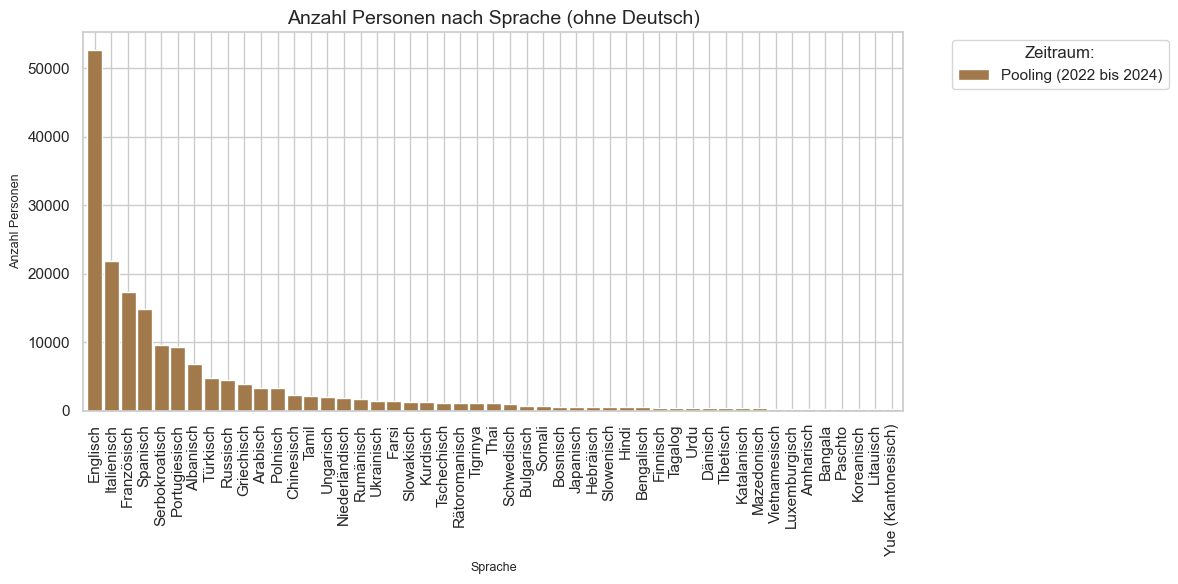

In [33]:
# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', # barh für horizontale Balken, bar für vertikale Balken
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Anzahl Personen nach Sprache (ohne Deutsch)', fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Sprache', fontsize=9)
ax.set_ylabel('Anzahl Personen', fontsize=9)

# Legende anpassen
plt.legend(title='Zeitraum:', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [34]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['Sprache'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = zuericolors_qual12da+zuericolors_qual12br+zuericolors_qual12+zuericolors_div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Deutsch': '#0017BF', 'Englisch': '#0072D7', 'Italienisch': '#00A5D2', 'Französisch': '#5E359A', 'Spanisch': '#BA0062', 'Serbokroatisch': '#DA5563', 'Portugiesisch': '#00615D', 'Albanisch': '#00770F', 'Türkisch': '#7BA600', 'Russisch': '#7B4100', 'Griechisch': '#DC5500', 'Arabisch': '#DA9C00', 'Polnisch': '#5D4BFE', 'Chinesisch': '#4AA9FF', 'Tamil': '#55FFFF', 'Ungarisch': '#986AD5', 'Niederländisch': '#FC4C99', 'Rumänisch': '#FF919A', 'Farsi': '#349894', 'Ukrainisch': '#44B14A', 'Slowakisch': '#B7E14E', 'Kurdisch': '#B97624', 'Tschechisch': '#FF7231', 'Rätoromanisch': '#FFD736', 'Tigrinya': '#3431DE', 'Thai': '#0A8DF6', 'Schwedisch': '#23C3F1', 'Bulgarisch': '#7B4FB7', 'Somali': '#DB247D', 'Bosnisch': '#FB737E', 'Japanisch': '#007C78', 'Hebräisch': '#1F9E31', 'Slowenisch': '#99C32E', 'Hindi': '#9A5B01', 'Bengalisch': '#FF720C', 'Finnisch': '#FBB900', 'Urdu': '#782600', 'Tagalog': '#CC4309', 'Dänisch': '#FF720C', 'Katalanisch': '#FFBC88', 'Tibetisch': '#E4E0DF', 'M

##### Anzahl Personen nach Sprache

In [35]:
data2betested.columns

Index(['Zeitraum', 'Sprache', 'AntBev', 'AnzBev', 'untAntBevKI', 'obAntBevKI', 'untAnzBevKI',
       'obAnzBevKI'],
      dtype='object')

In [36]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index()
    ,levels=['Zeitraum', 'Sprache']
    ,values="AnzBev"
    ,color="Sprache"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=900               
    #,margin_val_bottom=25
    ,myHeaderTitle="Anzahl Personen nach Sprache"
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x00000222939D5ED0>, 'Zeitraum', 'Sprache']
Typ von path: <class 'list'>


In [37]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index()
    ,levels=['Zeitraum', 'Sprache']
    ,values="AntBev"
    ,color="Sprache"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=900               
    #,margin_val_bottom=25
    ,myHeaderTitle="Anteil Personen nach Sprache"
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000022293AB53D0>, 'Zeitraum', 'Sprache']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=472&e=295NOa)**

---------------------------------------------------------------------------